# Step 1: Generate CropFormer Mask Cache for `room0`

This notebook creates the shared 2D mask cache used by all later comparison pipelines:

1. Original MaskClustering with geometric view consensus
2. Query-free Qwen3-VL scoring
3. MLP fusion over geometry + Qwen features

Target output:

```text
data/replica/room0/output/mask/<frame_id>.png
```

Run the cells one by one. Stop at the first failed check instead of pressing Run All.

## 1. Configure paths

Start with one scene only. Change `SCENE` later if `room0` works.

In [2]:
from pathlib import Path
import os
import sys

SCENE = "room0"
CONFIDENCE_THRESHOLD = 0.5

def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "MaskClustering").is_dir() and (path / "Project").is_dir():
            return path
    raise RuntimeError("Could not find repository root")

REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / "data" / "replica"
SCENE_ROOT = DATA_ROOT / SCENE
RGB_DIR = SCENE_ROOT / "color"
MASK_OUTPUT_DIR = SCENE_ROOT / "output" / "mask"

THIRD_PARTY = REPO_ROOT / "MaskClustering" / "third_party"
DETECTRON2_DIR = THIRD_PARTY / "detectron2"
CROPFORMER_DIR = DETECTRON2_DIR / "projects" / "CropFormer"
CROPFORMER_DEMO_DIR = CROPFORMER_DIR / "demo_cropformer"
CONFIG_FILE = CROPFORMER_DIR / "configs" / "entityv2" / "entity_segmentation" / "mask2former_hornet_3x.yaml"

# Set this env var or paste the checkpoint path here if needed.
CKPT_PATH = "/rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/checkpoints/Mask2Former_hornet_3x_576d0b.pth"

print("Repo root       :", REPO_ROOT)
print("Scene          :", SCENE)
print("RGB dir        :", RGB_DIR)
print("Mask output dir:", MASK_OUTPUT_DIR)
print("CropFormer dir :", CROPFORMER_DIR)
print("Config file    :", CONFIG_FILE)
print("Checkpoint     :", CKPT_PATH or "<not set yet>")

Repo root       : /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping
Scene          : room0
RGB dir        : /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/replica/room0/color
Mask output dir: /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/replica/room0/output/mask
CropFormer dir : /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/MaskClustering/third_party/detectron2/projects/CropFormer
Config file    : /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/MaskClustering/third_party/detectron2/projects/CropFormer/configs/entityv2/entity_segmentation/mask2former_hornet_3x.yaml
Checkpoint     : /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/checkpoints/Mask2Former_hornet_3x_576d0b.pth


## 2. Check data and CropFormer files

This cell only checks paths. It does not run the model.

In [3]:
def status(path: Path):
    return "OK" if path.exists() else "MISSING"

checks = {
    "scene root": SCENE_ROOT,
    "rgb dir": RGB_DIR,
    "detectron2 dir": DETECTRON2_DIR,
    "CropFormer dir": CROPFORMER_DIR,
    "CropFormer demo dir": CROPFORMER_DEMO_DIR,
    "CropFormer config": CONFIG_FILE,
    "mask_predict.py": CROPFORMER_DEMO_DIR / "mask_predict.py",
}

for name, path in checks.items():
    print(f"{name:22s} {status(path):8s} {path}")

rgb_files = sorted(RGB_DIR.glob("*.jpg")) if RGB_DIR.exists() else []
print("\nRGB frames found:", len(rgb_files))
print("First frames:", [p.name for p in rgb_files[:5]])

if not rgb_files:
    raise RuntimeError("No RGB frames found. Check DATA_ROOT and SCENE.")
if not CONFIG_FILE.exists():
    raise RuntimeError("CropFormer config missing. Finish setup_env.sh / CropFormer setup first.")

scene root             OK       /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/replica/room0
rgb dir                OK       /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/replica/room0/color
detectron2 dir         OK       /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/MaskClustering/third_party/detectron2
CropFormer dir         OK       /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/MaskClustering/third_party/detectron2/projects/CropFormer
CropFormer demo dir    OK       /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/MaskClustering/third_party/detectron2/projects/CropFormer/demo_cropformer
CropFormer config      OK       /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/MaskClustering/third_party/detectron2/projects/CropFormer/configs/entityv2/entity_segmentation/mask2former_hornet_3x.yaml
mask_predict.py        OK       /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/MaskClustering/third_party/detectron2/pro

## 3. Check Python/CUDA imports

For mask generation, `detectron2` and `MultiScaleDeformableAttention` must import successfully.

In [4]:
import torch
print("torch:", torch.__version__, "cuda:", torch.version.cuda, "available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

import detectron2
print("detectron2 ok")

import MultiScaleDeformableAttention
print("MultiScaleDeformableAttention ok")

torch: 2.0.0 cuda: 11.8 available: True
gpu: NVIDIA GeForce RTX 3090
detectron2 ok
MultiScaleDeformableAttention ok


## 4. Set or verify the CropFormer checkpoint

The checkpoint is not stored in git. Either set `CROPFORMER_CKPT` before launching Jupyter or paste the absolute path below.

Expected checkpoint: `model_final_entityv2_hornet_3x.pth`.

In [5]:
# If CKPT_PATH printed as '<not set yet>' above, paste the absolute path here:
CKPT_PATH = "/rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/checkpoints/Mask2Former_hornet_3x_576d0b.pth"

if not CKPT_PATH:
    raise RuntimeError("Set CKPT_PATH first. Paste the checkpoint path in this cell and rerun it.")

CKPT_PATH = str(Path(CKPT_PATH).expanduser().resolve())
if not Path(CKPT_PATH).exists():
    raise FileNotFoundError(CKPT_PATH)

print("Checkpoint OK:", CKPT_PATH)

Checkpoint OK: /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/checkpoints/Mask2Former_hornet_3x_576d0b.pth


## 5. Build the exact CropFormer command

This cell prints the command first. Read it once before running the next cell.

In [6]:
cmd = [
    sys.executable,
    "mask_predict.py",
    "--config-file", str(CONFIG_FILE),
    "--root", str(DATA_ROOT),
    "--image_path_pattern", "color/*.jpg",
    "--dataset", "replica",
    "--seq_name_list", SCENE,
    "--confidence-threshold", str(CONFIDENCE_THRESHOLD),
    "--opts", "MODEL.WEIGHTS", CKPT_PATH,
]

print("Working directory:")
print(CROPFORMER_DEMO_DIR)
print("\nCommand:")
print(" ".join(cmd))
print("\nOutput will be written to:")
print(MASK_OUTPUT_DIR)

Working directory:
/rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/MaskClustering/third_party/detectron2/projects/CropFormer/demo_cropformer

Command:
/rhome/flowis153/miniconda3/envs/maskclustering/bin/python mask_predict.py --config-file /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/MaskClustering/third_party/detectron2/projects/CropFormer/configs/entityv2/entity_segmentation/mask2former_hornet_3x.yaml --root /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/replica --image_path_pattern color/*.jpg --dataset replica --seq_name_list room0 --confidence-threshold 0.5 --opts MODEL.WEIGHTS /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/checkpoints/Mask2Former_hornet_3x_576d0b.pth

Output will be written to:
/rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/replica/room0/output/mask


## 6. Run CropFormer for this scene

This is the expensive cell. It writes one mask PNG per RGB frame.

If it fails, stop here and inspect the error before rerunning.

In [7]:
import subprocess

MASK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
result = subprocess.run(cmd, cwd=CROPFORMER_DEMO_DIR, text=True)
if result.returncode != 0:
    raise RuntimeError(f"CropFormer failed with exit code {result.returncode}")

print("CropFormer finished")

/rhome/flowis153/miniconda3/envs/maskclustering/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/rhome/flowis153/miniconda3/envs/maskclustering/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


Using PyTorch large kernel dw conv impl
[GConvNet]: convert str gconv to func
[gconv] 2 order with dims= [96, 192] scale=0.3333
[gconv] 2 order with dims= [96, 192] scale=0.3333
[gconv] 3 order with dims= [96, 192, 384] scale=0.3333
[gconv] 3 order with dims= [96, 192, 384] scale=0.3333
[gconv] 3 order with dims= [96, 192, 384] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.33

100%|██████████| 1/1 [01:23<00:00, 83.75s/it]


CropFormer finished


## 7. Verify mask cache

Check that mask files exist and that their count roughly matches the RGB frames.

In [8]:
import cv2
import numpy as np

mask_files = sorted(MASK_OUTPUT_DIR.glob("*.png"), key=lambda p: int(p.stem))
print("RGB frames :", len(rgb_files))
print("Mask files :", len(mask_files))
print("Output dir :", MASK_OUTPUT_DIR)
print("First masks:", [p.name for p in mask_files[:5]])

if not mask_files:
    raise RuntimeError("No mask files were created.")

sample = cv2.imread(str(mask_files[0]), cv2.IMREAD_UNCHANGED)
print("Sample mask:", mask_files[0].name, "shape:", sample.shape, "dtype:", sample.dtype)
print("Instance ids: min", int(sample.min()), "max", int(sample.max()), "unique", len(np.unique(sample)))

RGB frames : 200
Mask files : 200
Output dir : /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/replica/room0/output/mask
First masks: ['0.png', '1.png', '2.png', '3.png', '4.png']
Sample mask: 0.png shape: (360, 640) dtype: uint8
Instance ids: min 0 max 17 unique 18


## 8. Visual sanity check

Overlay one generated mask map next to the RGB frame.

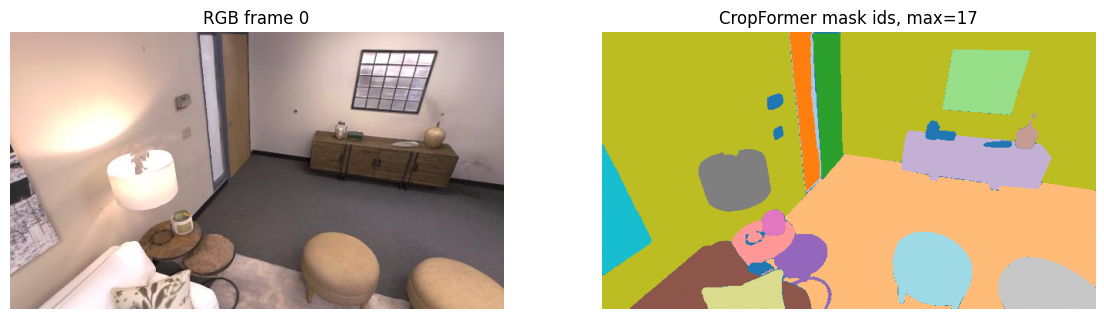

In [9]:
import matplotlib.pyplot as plt

sample_frame = int(mask_files[0].stem)
rgb_path = RGB_DIR / f"{sample_frame}.jpg"
mask_path = MASK_OUTPUT_DIR / f"{sample_frame}.png"

rgb = cv2.imread(str(rgb_path))
rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(rgb)
axes[0].set_title(f"RGB frame {sample_frame}")
axes[0].axis("off")
axes[1].imshow(mask, cmap="tab20")
axes[1].set_title(f"CropFormer mask ids, max={int(mask.max())}")
axes[1].axis("off")
plt.show()

## Result

If the checks above pass, the shared mask cache for this scene is ready:

```text
data/replica/room0/output/mask/
```

Next step: run original MaskClustering on this exact mask cache and record the baseline AP/mAP.